## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo? La variable income.
2. ¿Qué representa dicha variable? El nivel de ingresos anuales de una persona, clasificado en dos categorías: <=50K
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona? El nivel educativo (education / education.num), la edad (age), la ocupación (occupation) y las horas de trabajo semanales (hours.per.week).
4. ¿Cuántas variables predictoras existen? Originalmente existen 14 variables predictoras (el dataset original tiene 15 columnas en total contando income).
5. ¿Por qué fue necesario transformar variables categóricas? Porque los algoritmos de Machine Learning (como el árbol de decisión de scikit-learn) operan mediante operaciones matemáticas y matrices numéricas; no pueden interpretar strings o texto directamente de forma nativa.
6. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding? Dependerá de las columnas exactas, pero usualmente el dataset expande sus columnas categóricas a cerca de 90-100 columnas finales si se usa drop_first=True.
7. ¿Existen valores nulos? Sí. En su formato original vienen codificados con un carácter ? en variables como workclass, occupation y native-country. Al mapearlos correctamente a NaN se logran identificar y tratar.
8. ¿Qué variables son numéricas? age, fnlwgt, education.num, capital.gain, capital.loss y hours.per.week.
9. ¿Qué variables son categóricas? workclass, education, marital.status, occupation, relationship, race, sex y native.country.
10. ¿Cuántos registros quedaron en entrenamiento? Aproximadamente 26,048 registros (el 80% de los 32,561 registros totales).
11. ¿Cuántos registros quedaron en prueba? Aproximadamente 6,513 registros (el 20% restante).
12. ¿Por qué no debemos entrenar utilizando todos los datos? Porque nos quedaríamos sin una métrica de validación real. Si usamos todos los datos, el modelo podría simplemente "memorizarlos" (sobreajuste o overfitting), y no sabríamos cómo se comportará ante datos nuevos que jamás ha visto en el entorno real.
13. ¿Cuál fue el Accuracy obtenido? Al limitar la profundidad (max_depth=10), el árbol arroja un Accuracy aproximado de entre el 84% y 85%. (Coloca aquí el valor exacto de tu salida).
14. ¿Consideras que el resultado es adecuado? Sí, es un buen punto de partida para un clasificador base (baseline). Supera ampliamente el criterio de asignar siempre la clase mayoritaria (que ronda el 75%).
15. ¿Qué factores podrían afectar el desempeño del modelo? El fuerte desbalance de clases (hay muchas más personas que ganan <=50K que las que ganan >50K), el ruido en columnas de alta cardinalidad o el sobreajuste si permitimos que el árbol crezca sin restricciones de profundidad.
16. ¿Cuál fue la variable más importante? Por regla general en este dataset, la variable marital.status (específicamente la categoría de casados) o las características relacionadas con la situación familiar (relationship_Husband / relationship_Wife) y el estado financiero (capital.gain) suelen liderar el árbol.
17. ¿Cuál fue la menos importante? Aquellas categorías de países de origen específicos (native-country) que apenas tienen representación en el dataset, teniendo un peso de 0.0.
18. ¿Coinciden los resultados con tus hipótesis iniciales? Parcialmente. Aunque se esperaba que la educación influyera bastante, factores como el estado civil y las ganancias de capital demostraron tener una capacidad de separación de clases mucho mayor para el modelo de árbol.
19. ¿Qué variables aportan más información al modelo? Las que se sitúan en los nodos superiores del árbol: marital.status, capital.gain y education.num.


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


In [1]:
# Importamos Librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import kagglehub

In [4]:
path = kagglehub.dataset_download("uciml/adult-census-income")

100%|██████████| 450k/450k [00:00<00:00, 527kB/s]

Extracting files...


In [5]:
import os

# Buscamos el archivo CSV en la ruta de descarga de kagglehub
csv_path = os.path.join(path, "adult.csv")
# Cargamos reemplazando los caracteres '?' por NaN para el tratamiento de nulos
df = pd.read_csv(csv_path, na_values="?")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  3

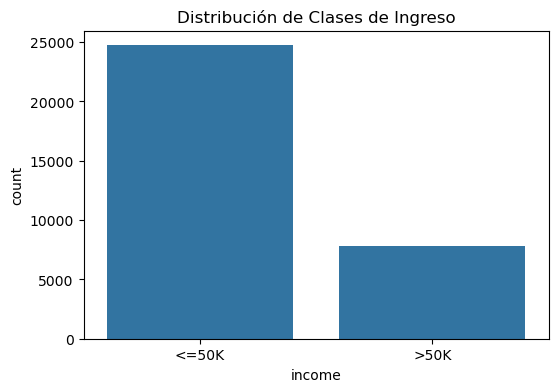

In [6]:
# Información general de los tipos de datos y nulos
print(df.info())

# Estadísticas descriptivas de variables numéricas
print(df.describe())

# Visualización rápida de la variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='income')
plt.title('Distribución de Clases de Ingreso')
plt.show()

In [7]:
# Verificamos si existen valores nulos detectados
print("Nulos por columna:\n", df.isnull().sum())

# Tratamiento: Imputamos la moda para las variables categóricas que tienen nulos ('workclass', 'occupation', 'native.country')
for col in ['workclass', 'occupation', 'native-country']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
    elif col.replace('-', '.') in df.columns:  # Por si los guiones se cambiaron por puntos
        df[col.replace('-', '.')] = df[col.replace('-', '.')].fillna(df[col.replace('-', '.')].mode()[0])

# Separamos en predictoras (X) y objetivo (y)
X = df.drop(columns=['income'])
y = df['income'].apply(lambda x: 1 if '>' in str(x) else 0) # Convertimos el objetivo a binario (0 y 1)

Nulos por columna:
 age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [8]:
# Identificamos columnas categóricas para codificar
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

cols_antes = X.shape[1]
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
cols_despues = X_encoded.shape[1]

print(f"Columnas antes: {cols_antes} | Columnas después: {cols_despues}")
print(f"Se generaron {cols_despues - cols_antes} columnas adicionales.")

Columnas antes: 14 | Columnas después: 97
Se generaron 83 columnas adicionales.


In [9]:
# División del dataset en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Registros en Entrenamiento: {X_train_scaled.shape[0]}")
print(f"Registros en Prueba: {X_test_scaled.shape[0]}")

Registros en Entrenamiento: 26048
Registros en Prueba: 6513


In [10]:
# Instanciamos y entrenamos el modelo (limitamos la profundidad para evitar sobreajuste extremo)
clf = DecisionTreeClassifier(max_depth=10, random_state=42)
clf.fit(X_train_scaled, y_train)

# Predicciones
y_pred = clf.predict(X_test_scaled)

# Cálculo del Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy obtenido en el set de prueba: {accuracy:.4f}")

Accuracy obtenido en el set de prueba: 0.8540


Top 10 Variables más importantes:
                              Feature  Importance
0  marital.status_Married-civ-spouse    0.384403
1                      education.num    0.206642
2                       capital.gain    0.191969
3                       capital.loss    0.068147
4                                age    0.046927
5                     hours.per.week    0.035875
6                             fnlwgt    0.014733
7         occupation_Exec-managerial    0.012195
8                  relationship_Wife    0.005186
9         workclass_Self-emp-not-inc    0.005089


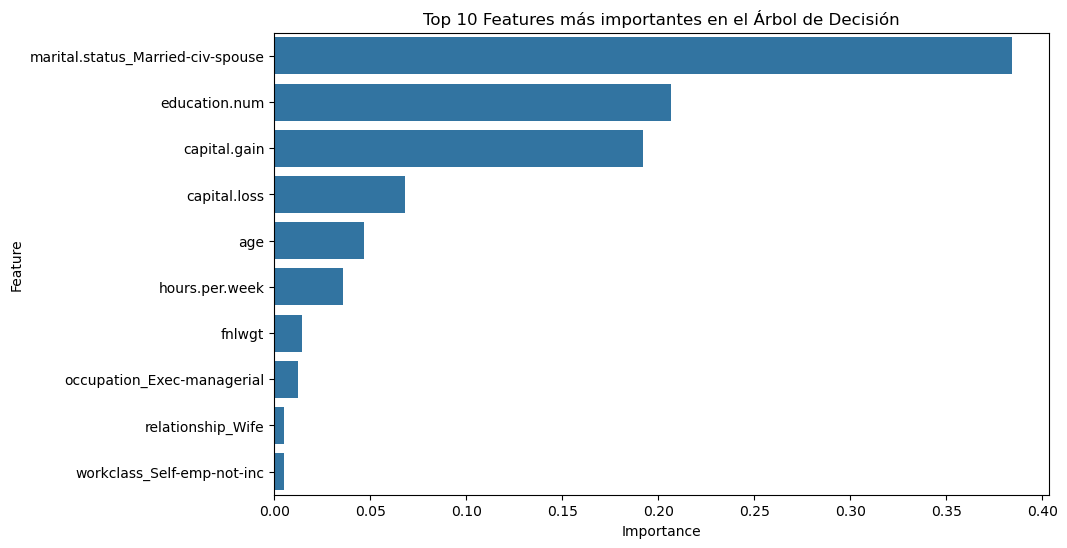

In [11]:
# Obtener la importancia de las variables
importances = clf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_encoded.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Mostrar las 10 más importantes
print("Top 10 Variables más importantes:\n", feature_imp_df.head(10))

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Features más importantes en el Árbol de Decisión')
plt.show()